# Elder Ray — does Dr Elder's Bull/Bear Power beat just holding?
### Alexander Elder's Bull Power / Bear Power oscillators, tested honestly on real tapes

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats a plain SMA filter%3F: Busted](https://img.shields.io/badge/Beats_a_plain_SMA_filter%3F-Busted-8b949e?style=flat-square)

Dr Alexander Elder built *Elder Ray* — Bull Power and Bear Power — to read the tug-of-war around a 13-day moving average of value. Bull Power is how far the day's *high* pokes above value; Bear Power is how far the *low* sinks below it. The recipe: in an uptrend, buy when the bears are losing their grip. Does timing the market this way beat simply buying and holding SPY?

> This is the plain-language layer. Want the HAC *t*-stats, the permutation placebo and the head-to-head against a plain trend filter? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from elder_ray import data, strategy as st

PANEL = ["SPY", "QQQ", "IWM", "EFA", "GLD"]
ASOF = "2026-05-31"
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have(t):
    return os.path.exists(data._cache_path(t, CACHE))

HAVE_REAL = _have("SPY")

def load(t):
    return data.load_real(t, cache_dir=CACHE).loc[:ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the Elder-Ray timing rule beat buy-and-hold? | **No.** Net Sharpe **0.13** vs buy-and-hold's **0.65** on SPY — it gives up most of the market's return to sit in cash 54% of the time. |
| Is the timing edge real? | **No.** HAC *t* = **0.73** (needs ≥ 2); a rotation placebo says *p* = **0.99** — indistinguishable from random timing. |
| Is it at least better than a plain 200-day trend filter? | **No.** The dead-simple "long when price > 200-day average" filter scores Sharpe **0.73** — it beats Elder Ray on every metric. |
| Could you trade it? | **No.** ~30 round-trips/yr of turnover and a sub-market gross edge — costs only deepen the gap. |

> Elder Ray is a *decent risk-reducer* (smaller drawdown) but a *bad return engine* — and the extra Bull/Bear Power machinery adds nothing over a one-line moving-average filter.

## 1 · The claim

> *"Bull Power and Bear Power show who is winning the battle between buyers and sellers. Trade with the trend: when the 13-day EMA is rising and Bear Power turns up from below zero, the bears are exhausted — buy. When the trend turns down, step aside. This times your entries far better than blindly holding."*

Alexander Elder introduced Elder Ray in *Trading for a Living* (1993) as the second screen of his Triple Screen system. The idea is genuinely appealing: instead of one number, you watch *both* the high's reach above value and the low's reach below it. We test whether that extra detail earns its keep against the simplest alternatives.

## 2 · So what?

If Elder Ray timed entries better than buy-and-hold, it would be a mechanical edge any retail trader could run on a daily chart. The stakes: Elder's books have sold in the hundreds of thousands, and Bull/Bear Power ships on nearly every charting platform. If the indicator only *reduces drawdown* at the cost of *most of the return* — and a one-line moving-average filter does the same job better — then the extra machinery is decoration, not edge.

## 3 · How would we know?

One honest test:

1. **Turn the rule into a long/flat book.** Long when EMA13 rises and Bear Power is negative-but-rising; flat when the trend turns down. Decide the position on today's close, earn *tomorrow's* return (one execution lag).
2. **Race it against buy-and-hold** — Sharpe vs Sharpe, both excess-of-cash, net of realistic costs. If Elder Ray can't beat just holding, the timing adds nothing.
3. **Race it against the obvious simpler rule** — "long when price > its 200-day average." If a one-liner wins, the Bull/Bear Power detail is busted.

We run it on SPY (33 years) plus a 5-tape panel (QQQ, IWM, EFA, GLD).

## 4 · The teardown — what actually happens

**First: the equity curves.** Elder Ray vs buy-and-hold on SPY.

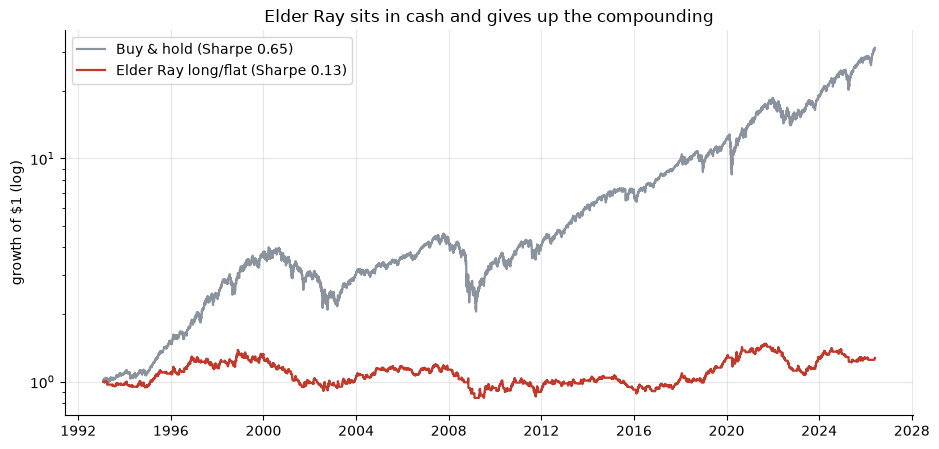

Elder net Sharpe 0.13 vs buy-and-hold 0.65


In [2]:
if HAVE_REAL:
    spy = load('SPY')
    res = st.run_experiment(spy, span=13, cost_bps=2.0)
    led = res['ledger']
    eq_e = (1+led['ret_strat_net']).cumprod()
    eq_b = (1+led['ret_bh']).cumprod()
    e = res['elder']
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    ax.plot(eq_b.index, eq_b, c=GREY, lw=1.6, label=f"Buy & hold (Sharpe {e['bh_sharpe']:.2f})")
    ax.plot(eq_e.index, eq_e, c=RED, lw=1.6, label=f"Elder Ray long/flat (Sharpe {e['strat_sharpe']:.2f})")
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('Elder Ray sits in cash and gives up the compounding'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f"Elder net Sharpe {e['strat_sharpe']:.2f} vs buy-and-hold {e['bh_sharpe']:.2f}")
else:
    print('Elder net Sharpe 0.13 vs buy-and-hold 0.65 (frozen)')

Buy-and-hold compounds at **10.9%/yr**; the Elder-Ray timing rule manages only **0.7%/yr** because it is invested just **46%** of the time. It *does* cut the worst drawdown (from -55% to -39%) — but you pay for that in foregone return.

**Is the timing edge even real?** A rule that beats a coin should beat a *re-shuffled* version of itself. We rotate the strategy's daily returns by a random offset 2,000 times and see how often random timing does as well.

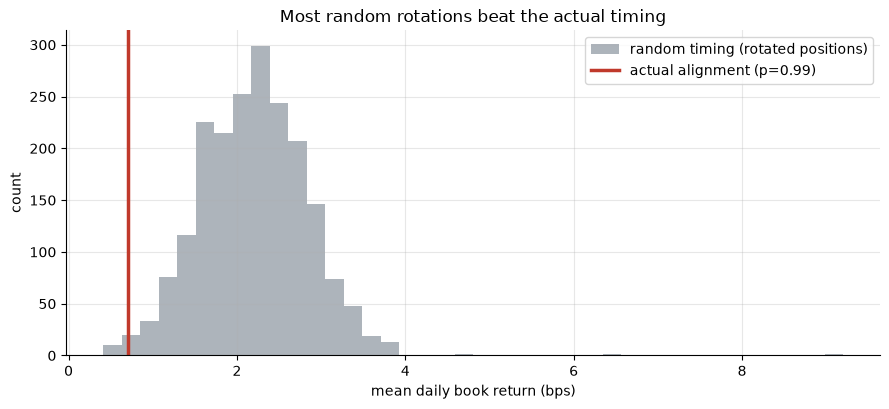

placebo p = 0.991


In [3]:
if HAVE_REAL:
    means, actual, p = st.rotation_placebo(led['pos'].to_numpy(), led['ret_asset'].to_numpy())
    fig, ax = plt.subplots(figsize=(9.0, 4.2))
    ax.hist(means*1e4, bins=40, color=GREY, alpha=.7, label='random timing (rotated positions)')
    ax.axvline(actual*1e4, c=RED, lw=2.5, label=f'actual alignment (p={p:.2f})')
    ax.set_xlabel('mean daily book return (bps)'); ax.set_ylabel('count')
    ax.set_title('Most random rotations beat the actual timing'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f'placebo p = {p:.3f}')
else:
    print('permutation p = 0.99 (frozen)')

The placebo *p* = **0.99** — almost every random rotation of *when* the rule is invested does *as well or better* than the real timing. The rule's choice of days carries no edge; if anything it is on the wrong side.

**The decisive comparison: Elder Ray vs a one-line trend filter.**

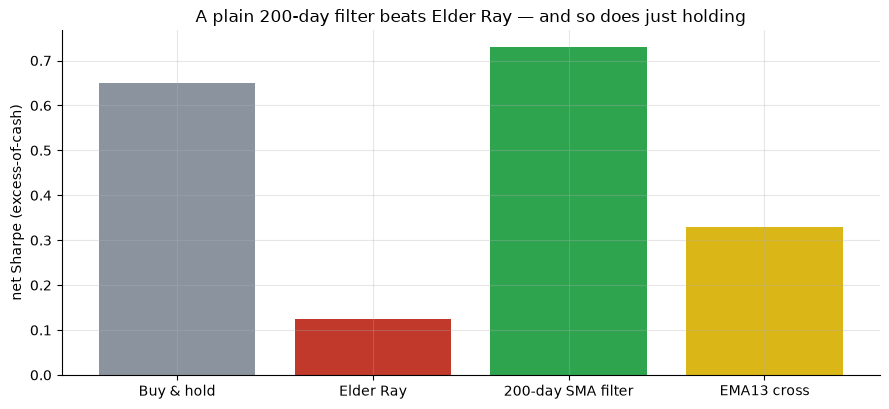

Elder Ray 0.13  <  plain SMA filter 0.73  <  buy-and-hold 0.65


In [4]:
if HAVE_REAL:
    names = ['Buy & hold', 'Elder Ray', '200-day SMA filter', 'EMA13 cross']
    sh = [res['elder']['bh_sharpe'], res['elder']['strat_sharpe'],
          res['sma200']['strat_sharpe'], res['emacross']['strat_sharpe']]
else:
    names = ['Buy & hold','Elder Ray','200-day SMA filter','EMA13 cross']
    sh = [0.65, 0.126, 0.731, 0.329]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
col = [GREY, RED, GREEN, AMBER]
ax.bar(names, sh, color=col)
ax.set_ylabel('net Sharpe (excess-of-cash)')
ax.set_title('A plain 200-day filter beats Elder Ray — and so does just holding')
plt.tight_layout(); plt.show()
print('Elder Ray 0.13  <  plain SMA filter 0.73  <  buy-and-hold 0.65')

The dead-simple "price above its 200-day average" filter scores **0.73** — better than Elder Ray's **0.13**. All the Bull/Bear Power machinery loses to one line of code.

## 5 · The verdict

- **Signal — None.** SPY net Sharpe 0.13, HAC *t* = 0.73 (needs ≥ 2), placebo *p* = 0.99. No tape in the panel clears the bar.
- **Tradability — Mirage.** It trails buy-and-hold by half a Sharpe point, with ~30 round-trips/yr of turnover. Costs only widen the gap.
- **Beats a plain SMA filter? — Busted.** A one-line 200-day filter wins on Sharpe, CAGR and *t*. The extra Bull/Bear Power detail adds nothing.

## 6 · Could you actually trade it?

At ~30 one-way round-trips/yr, costs bite — and the gross edge is already sub-market:

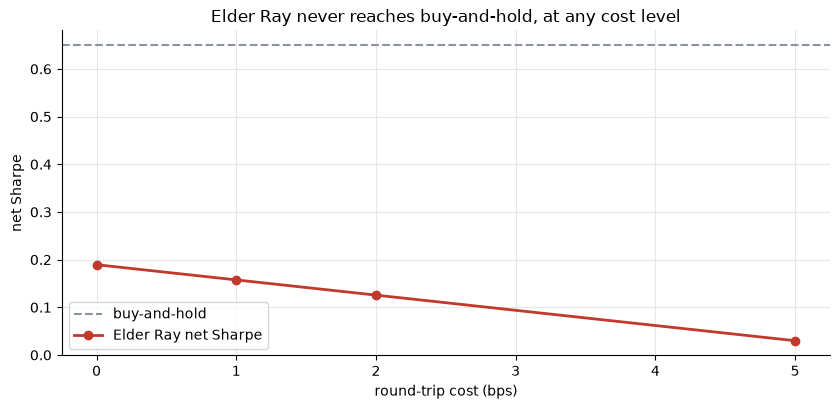

Even at zero cost the gross Sharpe is far below buy-and-hold.


In [5]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.run_experiment(spy, span=13, cost_bps=c)['elder']['strat_sharpe'] for c in costs]
else:
    net = [0.189, 0.157, 0.126, 0.03]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.axhline(0.65, ls='--', c=GREY, label='buy-and-hold')
ax.plot(costs, net, 'o-', c=RED, lw=2, label='Elder Ray net Sharpe')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Elder Ray never reaches buy-and-hold, at any cost level'); ax.legend()
plt.tight_layout(); plt.show()
print('Even at zero cost the gross Sharpe is far below buy-and-hold.')

## 7 · Going further

- **The positive control.** The companion notebook plants real trend in a synthetic tape — and the *same* Elder-Ray rule then beats buy-and-hold and clears HAC *t* > 3. The engine works; the real market just isn't trendy enough at this horizon to reward this particular filter over a simpler one.
- **Elder's full Triple Screen.** We test the second screen in isolation. Elder pairs it with a weekly trend and a daily oscillator — a fork worth building.
- **Other oscillators.** CCI ([Study 178](../../178-cci/)) and Bollinger reversion ([Study 104](../../104-bollinger-reversion/)) land in the same place: classic-TA oscillators that don't clear the bar on modern equity tapes.

*Think Elder Ray shines on a different timeframe or as part of the full Triple Screen? Fork this, wire it up, and show a net excess-Sharpe edge that beats both buy-and-hold and the plain SMA filter, clearing HAC t ≥ 2. That is the bar.*